In [1]:
%load_ext autoreload
%autoreload 2

from collections.abc import Mapping, Sequence

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from pgmpy.estimators import (
    BayesianEstimator,
    ExpectationMaximization,
    MaximumLikelihoodEstimator,
)
from pgmpy.inference.CausalInference import CausalInference
from pgmpy.models import DiscreteBayesianNetwork

from src.model import fit_discrete_bayesian_model

/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("./data/processed/adult.csv")
df.head()

# Group the hours-per-week into categories
bins = [0, 20, 40, 60, 80, float("inf")]
labels = ["0-20", "21-40", "41-60", "61-80", "80+"]
df["hours-per-week"] = pd.cut(
    df["hours-per-week"], bins=bins, labels=labels, right=False
)

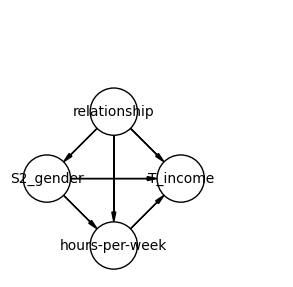

In [3]:
from src.graph import build_sfm, visualize_sfm

sfm = build_sfm(
    sensitive_attr="S2_gender",
    outcome_attr="T_income",
    confounder_attrs=["relationship"],
    mediator_attrs=["hours-per-week"],
)

visualize_sfm(sfm)


In [4]:
bn = fit_discrete_bayesian_model(
    sfm,
    df,
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

# bn = fit_discrete_bayesian_model(
#     sfm,
#     df,
#     estimator_instance=(
#         BayesianEstimator,
#         {"prior_type": "K2"},
#     ),
# )

# bn = fit_discrete_bayesian_model(
#     sfm,
#     df,
#     estimator_instance=(MaximumLikelihoodEstimator,),
# )

2026-03-06 11:22:29.048 | DEBUG    | src.model:fit_discrete_bayesian_model:31 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'N', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'N', 'capital-loss': 'N', 'hours-per-week': 'O', 'native-country': 'C', 'T_income': 'C'}


In [5]:
from legacy.causalfairness.bayesian import build_probabilities_multi_bayes

(
    P_y_given_x_z,
    P_y_given_x_z_w,
    P_w_given_x_z,
    P_z_given_x,
    P_z,
    w_cols,
    z_cols,
) = build_probabilities_multi_bayes(
    df,
    x_col="S2_gender",
    y_col="T_income",
    z_cols=["relationship"],
    w_cols=["hours-per-week"],
    alpha_y=1.0,
    alpha_w=1.0,
    alpha_z=1.0,
)

In [6]:
# from mpmath.tests.test_hp import b
# import numpy as np

# y_labels = bn.get_cpds("T_income").state_names["T_income"]
# w_labels = bn.get_cpds("hours-per-week").state_names["hours-per-week"]
# z_labels = bn.get_cpds("relationship").state_names["relationship"]
# x_labels = bn.get_cpds("S2_gender").state_names["S2_gender"]
# ve = VariableElimination(bn)
# # Compare P(y | x, w, z) from bn and legacy code
# for y_val in y_labels:
#     for w_val in w_labels:
#         for z_val in z_labels:
#             for x_val in x_labels:
#                 prob = P_y_given_x_z_w(y_val, x_val, z_val, w_val)
#                 print(
#                     f"P(T_income={y_val} | S2_gender={x_val}, relationship={z_val}, hours-per-week={w_val}) = {prob:.4f}"
#                 )
#                 bn_prob = ve.query(
#                     variables=["T_income"],
#                     evidence={
#                         "S2_gender": x_val,
#                         "relationship": z_val,
#                         "hours-per-week": w_val,
#                     },
#                 )
#                 print(bn_prob)

In [7]:
from src.effects import (
    spurious_effect,
    total_effect,
    total_variation,
)

tv = total_variation(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
tot_eff = total_effect(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
# total_effect_scm(bn, ("T_income", "<=50K"), "S2_gender", x0="Male", x1="Female")

se_male = spurious_effect(bn, ("T_income", "<=50K"), "S2_gender", "Male")
se_female = spurious_effect(bn, ("T_income", "<=50K"), "S2_gender", "Female")

print(tot_eff)
print(se_male)
print(se_female)
print(tv)
print(tot_eff + (se_female - se_male))

2026-03-06 11:22:29.302 | DEBUG    | src.effects:total_variation:203 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-06 11:22:29.303 | DEBUG    | src.effects:total_effect:104 - Computing total effect for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-06 11:22:29.306 | DEBUG    | src.effects:spurious_effect:152 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-03-06 11:22:29.308 | DEBUG    | src.effects:spurious_effect:152 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female


0.022491660596901886
-0.052267965181285736
0.11913998354642608
0.1938996093246137
0.1938996093246137


In [8]:
from legacy.causalfairness.general_effects import (
    spurious_effect,
    total_effect,
    tv_effect,
)

print(tv_effect("Male", "Female", "<=50K", P_y_given_x_z, P_z, P_z_given_x))
print(total_effect("Male", "Female", "<=50K", P_y_given_x_z, P_z))

0.19433842053432526
0.06447933032128374


In [9]:
from src.effects import natural_direct_effect, natural_indirect_effect

nde = natural_direct_effect(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
nie = natural_indirect_effect(bn, ("T_income", "<=50K"), "S2_gender", "Female", "Male")

2026-03-06 11:22:29.385 | DEBUG    | src.effects:natural_direct_effect:272 - Computing total effect for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female


2026-03-06 11:22:29.386 | DEBUG    | src.effects:natural_direct_effect:276 - Confounders: ['relationship'], Mediators: ['hours-per-week']
2026-03-06 11:22:29.405 | DEBUG    | src.effects:natural_direct_effect:321 - NDE first term: 0.7952360293568284, second term: 0.747972693178921
2026-03-06 11:22:29.405 | DEBUG    | src.effects:natural_indirect_effect:375 - Computing total effect for target=('T_income', '<=50K'), private_baseline=Female, private_mod=Male
2026-03-06 11:22:29.406 | DEBUG    | src.effects:natural_indirect_effect:379 - Confounders: ['relationship'], Mediators: ['hours-per-week']
2026-03-06 11:22:29.420 | DEBUG    | src.effects:natural_indirect_effect:423 - NIE first term: 0.7952360293568284, second term: 0.7704643537758229


In [10]:
nde

np.float64(0.047263336177907345)

In [11]:
# from src.effects import natural_direct_effect_scm, natural_indirect_effect_scm

# nde_scm = natural_direct_effect_scm(
#     bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female"
# )
# nie_scm = natural_indirect_effect_scm(
#     bn, ("T_income", "<=50K"), "S2_gender", "Female", "Male"
# )

In [18]:
from legacy.causalfairness.general_effects import (
    total_effect,
    dir_effect,
    ind_effect,
)

W_values = bn.get_cpds("hours-per-week").state_names["hours-per-week"]


print(
    dir_effect("Male", "Female", "<=50K", W_values, P_y_given_x_z_w, P_z, P_w_given_x_z)
)
print(
    ind_effect("Male", "Female", "<=50K", W_values, P_y_given_x_z_w, P_w_given_x_z, P_z)
)
print(total_effect("Male", "Female", "<=50K", P_y_given_x_z, P_z))


0.047265231188396505
0.025861339572709814
0.06447933032128374


In [17]:
nde, nie, tot_eff, nde - nie

(np.float64(0.047263336177907345),
 np.float64(0.02477167558100546),
 np.float64(0.022491660596901886),
 np.float64(0.022491660596901886))